## Audio Exploration

#### Importamos dependencias

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import librosa                  # per MFCC
from wav2vec import cutvowel, wav2vec
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


#### Cargamos nuestro json y nuestro archivo de audio .wav

In [3]:
with open("./vowels/alex.json") as f:
    data = json.load(f)

print("Número de segments:", len(data))
print(data[30])

# --------------------------
# Extracció de característiques
# --------------------------
X = []
y = []

wav_file = "./vowels/alex.wav"

Número de segments: 138
{'vocal': 'A', 'start': '14.55', 'end': '14.65'}


Recorremos cada segmento de audio, lo recortamos y extraemos características:
datos con wav2vec + MFCCs.
Luego las combinamos en un vector y guardamos su etiqueta.

In [4]:
for i in range(len(data)):
    start = float(data[i]["start"])
    end   = float(data[i]["end"])
    vocal = data[i]["vocal"]

    Fs, cut = cutvowel(wav_file, start, end)
    
    if len(cut) < 100:
        continue

    # MFCCs + wav2vec combinats
    vec_wav2vec = wav2vec(cut, Fs)

    # MFCC amb librosa
    cut_float = cut.astype(float)
    mfccs = librosa.feature.mfcc(y=cut_float, sr=Fs, n_mfcc=13)
    mfcc_mean = mfccs.mean(axis=1)

    # combinem característiques
    vec = np.concatenate([vec_wav2vec, mfcc_mean])
    X.append(vec)
    y.append(vocal)

X = np.array(X)
y = np.array(y)


/home/cristo/TIC/ai_projects/audio/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1632
  warnings.warn(
/home/cristo/TIC/ai_projects/audio/.venv/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=336
  warnings.warn(


Mostramos el tamaño de los datos:
X tiene 138 muestras con 16 características cada una,
y y tiene 138 etiquetas.

In [5]:
print("Dimensions X:", X.shape)
print("Dimensions y:", y.shape)

Dimensions X: (138, 16)
Dimensions y: (138,)


Mostramos las vocales

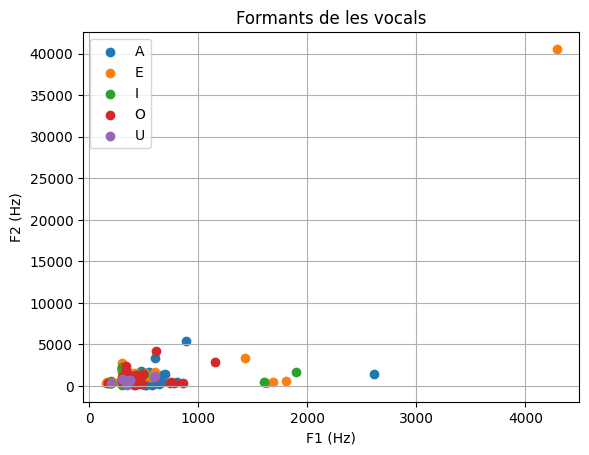

In [6]:
plt.figure()
for v in np.unique(y):
    idx = y == v
    plt.scatter(X[idx,0], X[idx,1], label=v)

plt.xlabel("F1 (Hz)")
plt.ylabel("F2 (Hz)")
plt.title("Formants de les vocals")
plt.legend()
plt.grid(True)
plt.show()

Normalizamos y dividimos los datos en train y en test

In [7]:
scaler = StandardScaler()
Xn = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    Xn, y, test_size=0.2, random_state=0, stratify=y
)

Definimos que modelos vamos a utilizar

In [8]:
models = {}

models["SVM"] = SVC(
    kernel="rbf",      # tipo de kernel
    C=10,              # parámetro de regularización
    gamma="scale",     # control del ancho del kernel
    class_weight="balanced"  # para clases desbalanceadas
)

# Altres models
models["KNN"] = KNeighborsClassifier(n_neighbors=5)
models["Logistic Regression"] = LogisticRegression(max_iter=500)
models["Decision Tree"] = DecisionTreeClassifier(max_depth=10, random_state=0)

Y finalizamos con el entrenamiento y con la evaluacion de los modelos

SVM
Accuracy: 0.5357142857142857
Classification report:
              precision    recall  f1-score   support

           A       0.58      0.78      0.67         9
           E       0.64      0.88      0.74         8
           I       0.33      0.33      0.33         3
           O       0.00      0.00      0.00         6
           U       0.00      0.00      0.00         2

    accuracy                           0.54        28
   macro avg       0.31      0.40      0.35        28
weighted avg       0.41      0.54      0.46        28



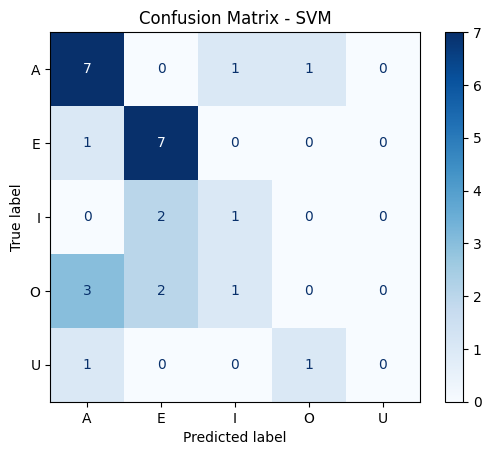

KNN
Accuracy: 0.5714285714285714
Classification report:
              precision    recall  f1-score   support

           A       0.78      0.78      0.78         9
           E       0.50      0.88      0.64         8
           I       0.00      0.00      0.00         3
           O       0.40      0.33      0.36         6
           U       0.00      0.00      0.00         2

    accuracy                           0.57        28
   macro avg       0.34      0.40      0.36        28
weighted avg       0.48      0.57      0.51        28



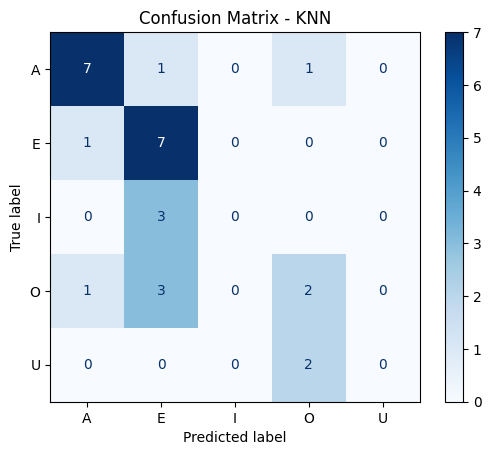

Logistic Regression
Accuracy: 0.6071428571428571
Classification report:
              precision    recall  f1-score   support

           A       0.70      0.78      0.74         9
           E       0.58      0.88      0.70         8
           I       0.00      0.00      0.00         3
           O       0.50      0.50      0.50         6
           U       0.00      0.00      0.00         2

    accuracy                           0.61        28
   macro avg       0.36      0.43      0.39        28
weighted avg       0.50      0.61      0.54        28



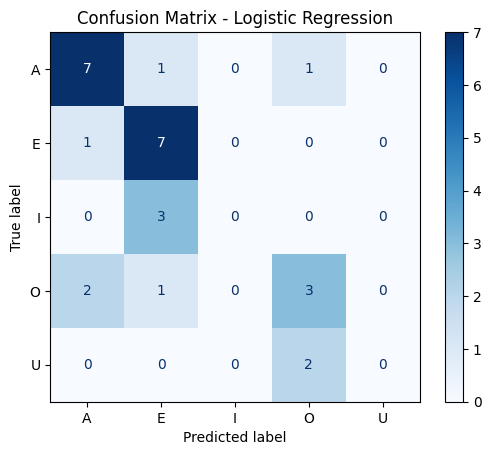

Decision Tree
Accuracy: 0.5714285714285714
Classification report:
              precision    recall  f1-score   support

           A       0.54      0.78      0.64         9
           E       0.56      0.62      0.59         8
           I       0.67      0.67      0.67         3
           O       0.50      0.17      0.25         6
           U       1.00      0.50      0.67         2

    accuracy                           0.57        28
   macro avg       0.65      0.55      0.56        28
weighted avg       0.58      0.57      0.55        28



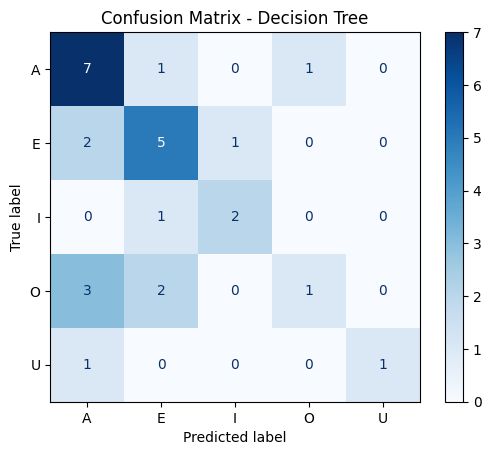

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{name}")
    print("Accuracy:", acc)
    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix dibujada
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
